<a href="https://colab.research.google.com/github/YaniaNada/Face-detection-using-ResNet-10-model/blob/main/face_detection_using_ResNet_10_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
import cv2
from google.colab.patches import cv2_imshow
import imutils

In [3]:
def read_image(image_path):
  image = cv2.imread(image_path)
  # cv2_imshow(input_image)

  return image

In [4]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt


--2025-11-20 19:54:02--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt.1’

deploy.prototxt.1   100%[===================>]  27.45K  --.-KB/s    in 0.002s  

2025-11-20 19:54:02 (16.1 MB/s) - ‘deploy.prototxt.1’ saved [28104/28104]



In [5]:
!wget -N https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel

--2025-11-20 19:54:02--  https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10666211 (10M) [application/octet-stream]
Saving to: ‘res10_300x300_ssd_iter_140000.caffemodel’

res10_300x300_ssd_i 100%[===================>]  10.17M  --.-KB/s    in 0.1s    

Last-modified header missing -- time-stamps turned off.
2025-11-20 19:54:03 (74.6 MB/s) - ‘res10_300x300_ssd_iter_140000.caffemodel’ saved [10666211/10666211]



In [6]:

# Load the DNN model
modelFile ="res10_300x300_ssd_iter_140000.caffemodel"

configFile = "deploy.prototxt"

net = cv2.dnn.readNetFromCaffe(configFile, modelFile)


In [7]:
def detect_imageblob(input_image):

  image = imutils.resize(input_image, width=400)

  (h, w) = image.shape[:2]

  blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 1.0,(300,300), (104.0, 177.0, 123.0))

  net.setInput(blob)

  detections = net.forward()

  return image, detections, h, w

In [8]:
def detect_faces(image, detections, h, w, confidence_threshold):

  for i in range(0, detections.shape[2]):

      confidence = detections[0, 0, i, 2]

      if confidence > confidence_threshold:
          box = detections[0, 0, i, 3:7] * [w, h, w, h]

          (startX, startY, endX, endY) = box.astype("int")

          cv2.rectangle(image, (startX, startY), (endX, endY), (0, 255, 0), 2)

  return image

Setting confidence score threshold to 0.5

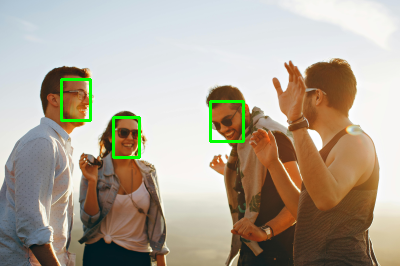

In [9]:
image_path = '/content/gdrive/MyDrive/Colab Notebooks/images/sunny-fashion-sunglasses-708392.jpg'

input_image = read_image(image_path)

confidence_threshold = 0.5
image, detections, h, w = detect_imageblob(input_image)
detect_faces (image, detections, h, w,confidence_threshold)
cv2_imshow(image)

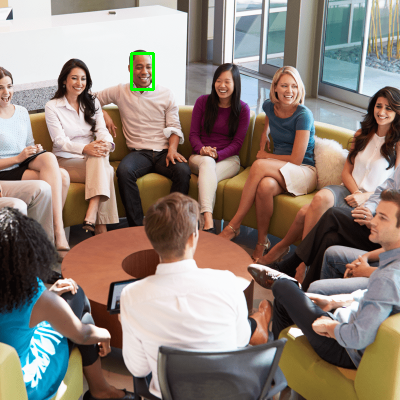

In [10]:
image_path = '/content/gdrive/MyDrive/Colab Notebooks/images/Group-of-people-sitting-in-circle-shutterstock_174539255.png'

input_image = read_image(image_path)

confidence_threshold = 0.5
image, detections, h, w = detect_imageblob(input_image)
detect_faces (image, detections, h, w, confidence_threshold)
cv2_imshow(image)

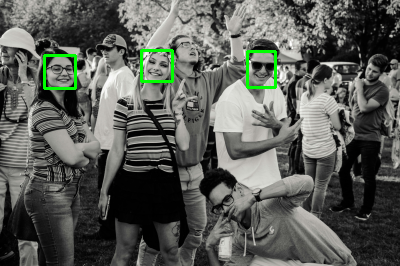

In [11]:
image_path = '/content/gdrive/MyDrive/Colab Notebooks/images/pexels-brett-sayles-1448371.jpg'

input_image = read_image(image_path)

confidence_threshold = 0.5
image, detections, h, w = detect_imageblob(input_image)
detect_faces (image, detections, h, w, confidence_threshold)
cv2_imshow(image)

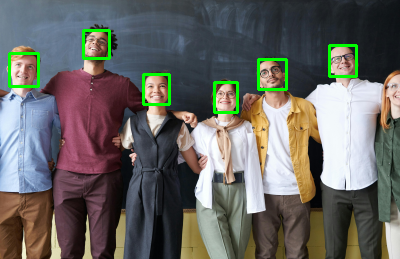

In [12]:
image_path = '/content/gdrive/MyDrive/Colab Notebooks/images/pexels-fauxels-3184398.jpg'

input_image = read_image(image_path)

confidence_threshold = 0.5
image, detections, h, w = detect_imageblob(input_image)
detect_faces (image, detections, h, w, confidence_threshold)
cv2_imshow(image)

Changing confidence score threshold to 0.2

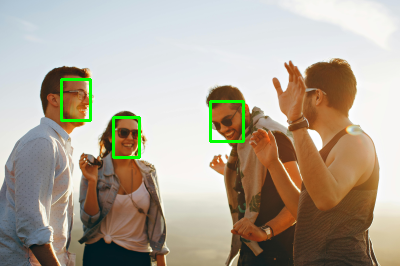

In [13]:
image_path = '/content/gdrive/MyDrive/Colab Notebooks/images/sunny-fashion-sunglasses-708392.jpg'

input_image = read_image(image_path)

confidence_threshold = 0.2
image, detections, h, w = detect_imageblob(input_image)
detect_faces (image, detections, h, w,confidence_threshold)
cv2_imshow(image)

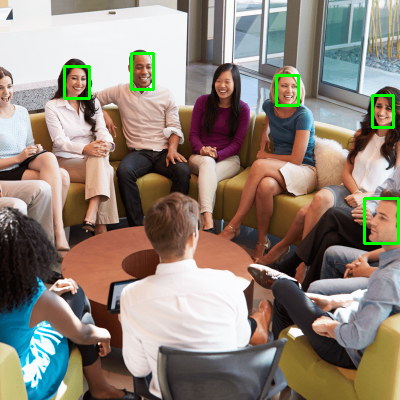

In [14]:
image_path = '/content/gdrive/MyDrive/Colab Notebooks/images/Group-of-people-sitting-in-circle-shutterstock_174539255.png'

input_image = read_image(image_path)

confidence_threshold = 0.2
image, detections, h, w = detect_imageblob(input_image)
detect_faces (image, detections, h, w, confidence_threshold)
cv2_imshow(image)

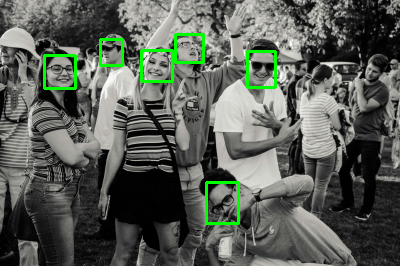

In [15]:
image_path = '/content/gdrive/MyDrive/Colab Notebooks/images/pexels-brett-sayles-1448371.jpg'

input_image = read_image(image_path)

confidence_threshold = 0.2
image, detections, h, w = detect_imageblob(input_image)
detect_faces (image, detections, h, w, confidence_threshold)
cv2_imshow(image)

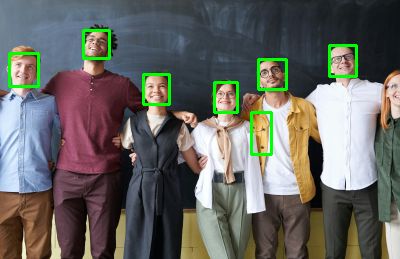

In [16]:
image_path = '/content/gdrive/MyDrive/Colab Notebooks/images/pexels-fauxels-3184398.jpg'

input_image = read_image(image_path)

confidence_threshold = 0.2
image, detections, h, w = detect_imageblob(input_image)
detect_faces (image, detections, h, w, confidence_threshold)
cv2_imshow(image)